# 🎯 Building Striker Archetypes

In modern scouting, we often look for specific **archetypes**—types of players that fit a tactical role—rather than just the "best" overall player. Using SkillCorner's combined Physical, Off-Ball Run (OBR), and Passing data, we can statistically define these roles.

## 📖 0. Introduction

This tutorial demonstrates how to combine disparate SkillCorner aggregate datasets to build composite profiles for strikers. We will focus on three common archetypes:

1.  **Direct Strikers**: Players who excel at making dangerous runs in behind and attacking the box with pace.
2.  **Link-Up Strikers**: Players who drop deep, come short, and contribute more through quick passing and collective build-up.
3.  **Target Men**: Physical presences in the box who are the primary outlets for crosses and high deliveries.

### Analysis Workflow
```mermaid
graph TD
    A[Load Aggregated Data] --> B[Merge Datasets]
    B --> C[Normalize Metrics P90/P30 TIP]
    C --> D[Filter Appearances]
    D --> E[Calculate Composite Z-Scores]
    E --> F[Visual Analysis]
    F --> G1[Ranking Bar Charts]
    F --> G2[Comparison Scatter Plots]
    F --> G3[Radar Profiles]
```

## 📋 1. Setup & Prerequisites


In [1]:
# Install SkillCorner Visualization library
!pip install skillcornerviz --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from skillcornerviz.standard_plots import bar_plot as bar
from skillcornerviz.standard_plots import scatter_plot as scatter
from skillcornerviz.standard_plots import radar_plot as rad

# Palette and Styling
SC_GREEN = '#00a82f'
pd.options.display.max_columns = None

# Data Paths
BASE_PATH = "../../../data/aggregates"


## 📥 2. Loading Aggregated Data


In [2]:
def load_aggregates(base_path):
    # Loading the three pillars of SkillCorner data
    physical = pd.read_csv(os.path.join(base_path, 'aus1league_physicalaggregates_20242025.csv'))
    obr = pd.read_csv(os.path.join(base_path, 'aus1league_obraggregates_20242025.csv'))
    passing = pd.read_csv(os.path.join(base_path, 'aus1league_passingaggregates_20242025.csv'))
    
    return physical, obr, passing

df_physical, df_obr, df_passing = load_aggregates(BASE_PATH)
print(f"Loaded {len(df_physical)} physical entries, {len(df_obr)} OBR entries, and {len(df_passing)} passing entries.")

Loaded 406 physical entries, 407 OBR entries, and 407 passing entries.


## 🔗 3. Merging & Dataset Preparation


In [22]:
merge_keys = ['player_id', 'team_id', 'position_group']

# Merge datasets on player and team identifiers
df_merged = pd.merge(df_physical, df_obr, on=merge_keys, how='inner', suffixes=('_phys', '_obr'))
df_merged = pd.merge(df_merged, df_passing, on=merge_keys, how='inner', suffixes=('', '_pass'))

print(f"Total unique players in merged dataset: {df_merged['player_name'].nunique()}")
df_merged.head()

Total unique players in merged dataset: 261


,player_name_phys,player_short_name_phys,player_id,player_birthdate_phys,team_name_phys,team_id,competition_name_phys,competition_id_phys,season_name_phys,season_id_phys,position_group,minutes_full_all,minutes_full_tip,minutes_full_otip,count_match,count_match_failed,total_distance_full_all,total_metersperminute_full_all,running_distance_full_all,hsr_distance_full_all,hsr_count_full_all,sprint_distance_full_all,sprint_count_full_all,hi_distance_full_all,hi_count_full_all,medaccel_count_full_all,highaccel_count_full_all,meddecel_count_full_all,highdecel_count_full_all,explacceltohsr_count_full_all,timetohsr_top3,explacceltosprint_count_full_all,timetosprint_top3,psv99,psv99_top5,total_distance_full_tip,total_metersperminute_full_tip,running_distance_full_tip,hsr_distance_full_tip,hsr_count_full_tip,sprint_distance_full_tip,sprint_count_full_tip,hi_distance_full_tip,hi_count_full_tip,medaccel_count_full_tip,highaccel_count_full_tip,meddecel_count_full_tip,highdecel_count_full_tip,explacceltohsr_count_full_tip,explacceltosprint_count_full_tip,total_distance_full_otip,total_metersperminute_full_otip,running_distance_full_otip,hsr_distance_full_otip,hsr_count_full_otip,sprint_distance_full_otip,sprint_count_full_otip,hi_distance_full_otip,hi_count_full_otip,medaccel_count_full_otip,highaccel_count_full_otip,meddecel_count_full_otip,highdecel_count_full_otip,explacceltohsr_count_full_otip,explacceltosprint_count_full_otip,competition_edition_id,competition_id_obr,competition_name_obr,season_id_obr,season_name_obr,player_name_obr,player_short_name_obr,player_birthdate_obr,team_name_obr,minutes,minutes_tip,minutes_otip,performance_count,performance_included_count,performance_failed_count,offballrun_count_total,offballrun_count_p30tip,behindrun_count_p30tip,comingshortrun_count_p30tip,crossreceiverrun_count_p30tip,droppingoffrun_count_p30tip,overlaprun_count_p30tip,pullinghalfspacerun_count_p30tip,pullingwiderun_count_p30tip,aheadoftheballrun_count_p30tip,supportrun_count_p30tip,underlaprun_count_p30tip,offballrun_count_shotwithin10s_p30tip,behindrun_count_shotwithin10s_p30tip,comingshortrun_count_shotwithin10s_p30tip,crossreceiverrun_count_shotwithin10s_p30tip,droppingoffrun_count_shotwithin10s_p30tip,overlaprun_count_shotwithin10s_p30tip,pullinghalfspacerun_count_shotwithin10s_p30tip,pullingwiderun_count_shotwithin10s_p30tip,aheadoftheballrun_count_shotwithin10s_p30tip,supportrun_count_shotwithin10s_p30tip,underlaprun_count_shotwithin10s_p30tip,offballrun_count_goalwithin10s_p30tip,behindrun_count_goalwithin10s_p30tip,comingshortrun_count_goalwithin10s_p30tip,crossreceiverrun_count_goalwithin10s_p30tip,droppingoffrun_count_goalwithin10s_p30tip,overlaprun_count_goalwithin10s_p30tip,pullinghalfspacerun_count_goalwithin10s_p30tip,pullingwiderun_count_goalwithin10s_p30tip,aheadoftheballrun_count_goalwithin10s_p30tip,supportrun_count_goalwithin10s_p30tip,underlaprun_count_goalwithin10s_p30tip,offballrun_count_targeted_p30tip,behindrun_count_targeted_p30tip,comingshortrun_count_targeted_p30tip,crossreceiverrun_count_targeted_p30tip,droppingoffrun_count_targeted_p30tip,overlaprun_count_targeted_p30tip,pullinghalfspacerun_count_targeted_p30tip,pullingwiderun_count_targeted_p30tip,aheadoftheballrun_count_targeted_p30tip,supportrun_count_targeted_p30tip,underlaprun_count_targeted_p30tip,offballrun_count_received_p30tip,behindrun_count_received_p30tip,comingshortrun_count_received_p30tip,crossreceiverrun_count_received_p30tip,droppingoffrun_count_received_p30tip,overlaprun_count_received_p30tip,pullinghalfspacerun_count_received_p30tip,pullingwiderun_count_received_p30tip,aheadoftheballrun_count_received_p30tip,supportrun_count_received_p30tip,underlaprun_count_received_p30tip,offballrun_avgdistance,behindrun_avgdistance,comingshortrun_avgdistance,crossreceiverrun_avgdistance,droppingoffrun_avgdistance,overlaprun_avgdistance,pullinghalfspacerun_avgdistance,pullingwiderun_avgdistance,aheadoftheballrun_avgdistance,supportrun_avgdistance,underlapr

## ⚖️ 4. Normalization & Filtering


In [23]:
# Filter for players with at least 5 matches for statistical relevance
df_filtered = df_merged[(df_merged['count_match'] >= 5)&(df_merged.position_group=='Center Forward')].copy()

# ⚖️ Normalization Step: Some local datasets contain absolute counters.
# We ensure everything is normalized to Per 90 or Per 30 TIP.

if 'hi_count_p90' not in df_filtered.columns and 'hi_count_full_all' in df_filtered.columns:
    # Calculate High Intensity Count per 90 minutes
    df_filtered['hi_count_p90'] = (df_filtered['hi_count_full_all'] / df_filtered['minutes_full_all']) * 90

metrics = [
    'psv99', 'hi_count_p90', 'behindrun_count_p30tip', 
    'crossreceiverrun_count_p30tip', 'comingshortrun_count_p30tip', 
    'aheadoftheballrun_count_p30tip', 'behindrun_count_dangerous_received_p30tip',
    'crossreceiverrun_count_dangerous_received_p30tip', 'aheadoftheballrun_count_dangerous_received_p30tip',
    'pass_count_quickpass_attempted_p30tip', 'pass_count_linebreak_attempted_p30tip',
    'pass_count_dangerous_attempted_p30tip', 'crossreceiverrun_count_shotwithin10s_p30tip'
]

df_archetype = df_filtered[[
    'player_id', 'player_name', 'player_short_name', 'position_group',
    'player_birthdate', 'team_name'
] + [m for m in metrics if m in df_filtered.columns]].copy()

print(f"Dataset ready for archetyping with {len(df_archetype)} players.")

Dataset ready for archetyping with 32 players.


## 📊 5. Archetype Calculation (Composite Z-Scores)


In [24]:
def calculate_composite_zscores(df, metrics_group1, metrics_group2, metrics_group3,
                                name_g1='direct', name_g2='linkup', name_g3='target'):
    df_result = df.copy()
    
    for name, metrics_list in zip([name_g1, name_g2, name_g3], [metrics_group1, metrics_group2, metrics_group3]):
        # Check for missing metrics in local data
        valid_metrics = [m for m in metrics_list if m in df.columns]
        
        # Calculate Z-score for each valid metric then average them for the composite
        raw_avg = ((df[valid_metrics] - df[valid_metrics].mean()) / df[valid_metrics].std()).mean(axis=1, skipna=True)
        # Re-normalize the composite itself
        df_result[name] = (raw_avg - raw_avg.mean()) / raw_avg.std()
        
    return df_result

direct_metrics = ['hi_count_p90', 'psv99', 'behindrun_count_p30tip', 'aheadoftheballrun_count_p30tip', 'behindrun_count_dangerous_received_p30tip']
linkup_metrics = ['comingshortrun_count_p30tip', 'pass_count_quickpass_attempted_p30tip', 'pass_count_linebreak_attempted_p30tip', 'pass_count_dangerous_attempted_p30tip']
target_metrics = ['crossreceiverrun_count_p30tip', 'crossreceiverrun_count_dangerous_received_p30tip', 'crossreceiverrun_count_shotwithin10s_p30tip']

df_scored = calculate_composite_zscores(
    df_archetype, direct_metrics, linkup_metrics, target_metrics,
    name_g1='Direct_Composite', name_g2='Linkup_Composite', name_g3='Target_Composite'
)
print("Archetype Z-scores calculated successfully.")

Archetype Z-scores calculated successfully.


## 🖼️ 6. Visualizing Archetype Profiles


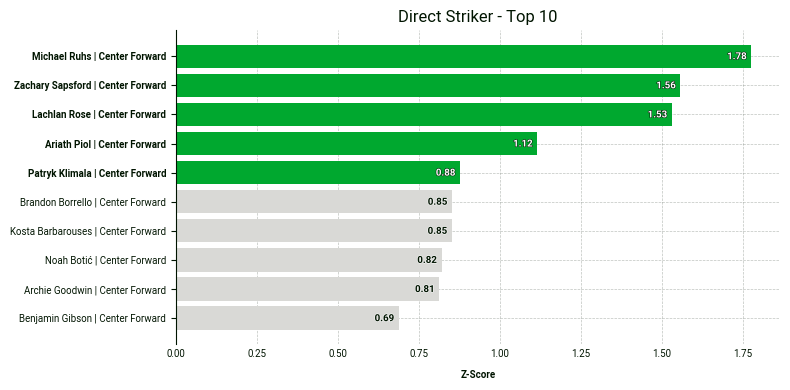

In [25]:
top_10_direct = df_scored.sort_values('Direct_Composite', ascending=False).head(10).copy()
top_10_direct['plot_label'] = top_10_direct['player_name'] + ' | ' + top_10_direct['position_group']
top_5_ids = top_10_direct['player_id'].head(5).tolist()

fig, ax = bar.plot_bar_chart(
    df=top_10_direct, metric='Direct_Composite', label='Z-Score',
    primary_highlight_group=top_5_ids, primary_highlight_color=SC_GREEN,
    add_bar_values=True, data_point_id='player_id', data_point_label='plot_label', plot_title='Direct Striker - Top 10'
)
plt.show()

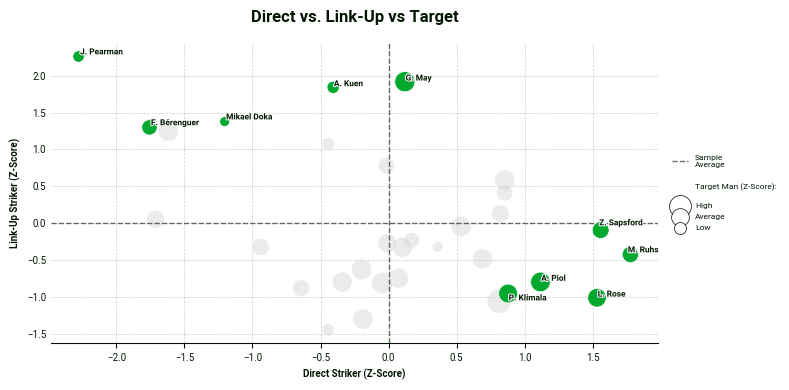

In [26]:
highlight_players = df_scored.sort_values('Direct_Composite', ascending=False).head(5)['player_id'].tolist() + \
                    df_scored.sort_values('Linkup_Composite', ascending=False).head(5)['player_id'].tolist()

fig, ax = scatter.plot_scatter(
    df=df_scored, x_metric='Direct_Composite', y_metric='Linkup_Composite', z_metric='Target_Composite',
    data_point_id='player_id', primary_highlight_group=list(set(highlight_players)),
    data_point_label='player_short_name', x_label='Direct Striker (Z-Score)', y_label='Link-Up Striker (Z-Score)',
    z_label='Target Man (Z-Score)', primary_highlight_color=SC_GREEN, plot_title='Direct vs. Link-Up vs Target'
)
plt.show()

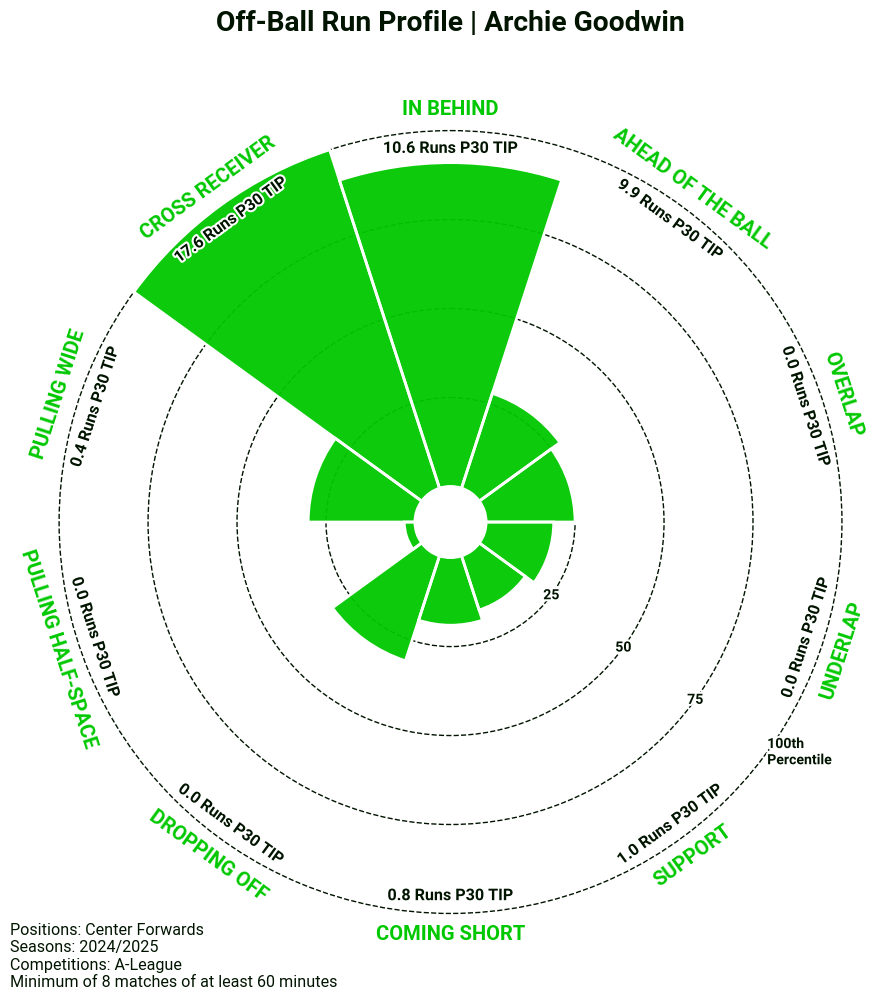

In [27]:
RUNS = {'crossreceiverrun_count_p30tip': 'Cross Receiver', 'behindrun_count_p30tip': ' In Behind', 
        'aheadoftheballrun_count_p30tip': 'Ahead Of The Ball', 'overlaprun_count_p30tip': 'Overlap', 
        'underlaprun_count_p30tip': 'Underlap', 'supportrun_count_p30tip': 'Support', 
        'comingshortrun_count_p30tip': 'Coming Short', 'droppingoffrun_count_p30tip': 'Dropping Off', 
        'pullinghalfspacerun_count_p30tip': 'Pulling Half-Space', 'pullingwiderun_count_p30tip': 'Pulling Wide'}

runs_df = df_filtered.copy()
fig, ax = rad.plot_radar(runs_df[runs_df['position_group'] == 'Center Forward'],
                         data_point_id='player_name', label='Archie Goodwin',
                         plot_title='Off-Ball Run Profile | Archie Goodwin', metrics=list(RUNS.keys()),
                         metric_labels=RUNS, percentiles_precalculated=False,
                         suffix=' Runs P30 TIP', filter_relevant=False, positions='Center Forwards',
                         matches=8, minutes=60, competitions='A-League', seasons='2024/2025', add_sample_info=True)
plt.show()

## ✅ Summary

In this notebook, we combined Physical, OBR, and Passing data to statistically define tactical archetypes for strikers. This methodology can be adapted to any position group and your own selection of metrics. Have a go !